In [ ]:
import pandas as pd
df = pd.read_csv('archive.csv')
df.info()

Saving archive.csv to archive.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 10 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Year                                         132 non-null    object 
 1   Punxsutawney Phil                            131 non-null    object 
 2   February Average Temperature                 123 non-null    float64
 3   February Average Temperature (Northeast)     123 non-null    float64
 4   February Average Temperature (Midwest)       123 non-null    float64
 5   February Average Temperature (Pennsylvania)  123 non-null    float64
 6   March Average Temperature                    123 non-null    float64
 7   March Average Temperature (Northeast)        123 non-null    float64
 8   March Average Temperature (Midwest)          123 non-null    float64
 9   March Average Temperature (Pennsylvania)  

In [ ]:
df = df.dropna()
df = df[df['Punxsutawney Phil'] != 'No Record']
df.head()

,Year,Punxsutawney Phil,February Average Temperature,February Average Temperature (Northeast),February Average Temperature (Midwest),February Average Temperature (Pennsylvania),March Average Temperature,March Average Temperature (Northeast),March Average Temperature (Midwest),March Average Temperature (Pennsylvania)
12,1898,Full Shadow,35.37,24.8,33.3,26.7,41.05,38.0,46.0,42.0
14,1900,Full Shadow,30.76,21.4,27.5,24.1,41.27,26.0,37.9,29.3
15,1901,Full Shadow,29.86,16.0,26.2,18.9,40.71,30.8,41.9,35.1
17,1903,Full Shadow,28.42,24.5,31.3,28.0,42.21,40.4,47.7,44.5
18,1904,Full Shadow,31.59,15.0,28.2,19.2,41.76,29.8,42.8,34.0


In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df['Phil_Encoded'] = encoder.fit_transform(df['Punxsutawney Phil'])

print(df[['Punxsutawney Phil', 'Phil_Encoded']].head())

   Punxsutawney Phil  Phil_Encoded
12       Full Shadow             0
14       Full Shadow             0
15       Full Shadow             0
17       Full Shadow             0
18       Full Shadow             0


In [ ]:
X = df.drop(['Year', 'Punxsutawney Phil', 'Phil_Encoded'], axis=1) #drops the columns that are not the temperature
y = df['Phil_Encoded']

print(X.head())
print(y.head())

    February Average Temperature  February Average Temperature (Northeast)  \
12                         35.37                                      24.8   
14                         30.76                                      21.4   
15                         29.86                                      16.0   
17                         28.42                                      24.5   
18                         31.59                                      15.0   

    February Average Temperature (Midwest)  \
12                                    33.3   
14                                    27.5   
15                                    26.2   
17                                    31.3   
18                                    28.2   

    February Average Temperature (Pennsylvania)  March Average Temperature  \
12                                         26.7                      41.05   
14                                         24.1                      41.27   
15                  

RandomForestClassifier from scikit-learn, with all the other numerical features in the dataset as your features.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = df.drop(['Year', 'Punxsutawney Phil', 'Phil_Encoded'], axis=1) #drops the columns that are not the temperature
y = df['Phil_Encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=0)

forest_model = RandomForestClassifier(random_state=0)
forest_model.fit(X_train, y_train)
y_pred = forest_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)


Accuracy: 0.9166666666666666


In [ ]:
from sklearn.ensemble import RandomForestClassifier
depth_values = [None, 5, 2]

for d in depth_values:
    model2 = RandomForestClassifier(max_depth=d, random_state=0)
    model2.fit(X_train, y_train)
    y_pred = model2.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print("Max depth =", d, "Accuracy =", acc)

#tested different depth values, but didn't change accuracy

Max depth = None Accuracy = 0.9166666666666666
Max depth = 5 Accuracy = 0.9166666666666666
Max depth = 2 Accuracy = 0.9166666666666666


In [ ]:
leaf_values = [1, 3, 5]

for m in leaf_values:
    model3 = RandomForestClassifier(min_samples_leaf=m, random_state=0)
    model3.fit(X_train, y_train)
    y_pred = model3.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print("Min samples per leaf =", m, "Accuracy =", acc)
#tested different leaf values, but didn't change accuracy

Min samples per leaf = 1 Accuracy = 0.9166666666666666
Min samples per leaf = 3 Accuracy = 0.9166666666666666
Min samples per leaf = 5 Accuracy = 0.9166666666666666


 feature_importances_ attribute of the RandomForestClassifier to find the relative importances of all the features in the model

In [ ]:
feature_names = X.columns.tolist()

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': forest_model.feature_importances_}).sort_values('Importance', ascending=False)

print(importance_df)

                                       Feature  Importance
4                    March Average Temperature    0.141976
0                 February Average Temperature    0.141042
6          March Average Temperature (Midwest)    0.136659
3  February Average Temperature (Pennsylvania)    0.128788
1     February Average Temperature (Northeast)    0.127499
7     March Average Temperature (Pennsylvania)    0.121797
5        March Average Temperature (Northeast)    0.104108
2       February Average Temperature (Midwest)    0.098131


Now lets see how accurate Phil is at predicting the weather!

In [ ]:
#anaylzing the data to see if Phil is accurate at predicting the weather
df['Temp_Change'] = df['March Average Temperature'] - df['February Average Temperature']
actual_outcomes = []
for change in df['Temp_Change']:
    if change > 5:             # if March is at least 5°F warmer, then it will be categorized as early spring
        actual_outcomes.append('Early Spring')
    else:
        actual_outcomes.append('Late Winter')
df['Actual Outcome'] = actual_outcomes
phil_predictions = []
for prediction in df['Punxsutawney Phil']:
    if prediction == 'Full Shadow':
        phil_predictions.append('Late Winter')
    else:
        phil_predictions.append('Early Spring')

df['Phil_Prediction'] = phil_predictions
accuracy = (df['Phil_Prediction'] == df['Actual Outcome']).mean()

print("Phil’s temperature-based forecasting accuracy:"+ str(round(accuracy * 100, 2)) + " %")


Phil’s temperature-based forecasting accuracy:31.9 %


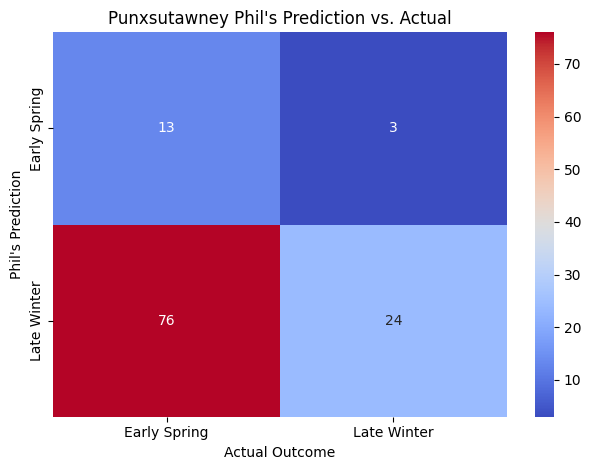

In [ ]:
#making a heatmap
import seaborn as sns
import matplotlib.pyplot as plt

#making a confusion matrix
order = ['Early Spring', 'Late Winter']
conf_matrix = pd.crosstab(df['Phil_Prediction'], df['Actual Outcome'])
conf_matrix = conf_matrix.reindex(index=order, columns=order, fill_value=0)

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='coolwarm')
plt.title("Punxsutawney Phil's Prediction vs. Actual")
plt.xlabel("Actual Outcome")
plt.ylabel("Phil's Prediction")
plt.tight_layout()
plt.show()

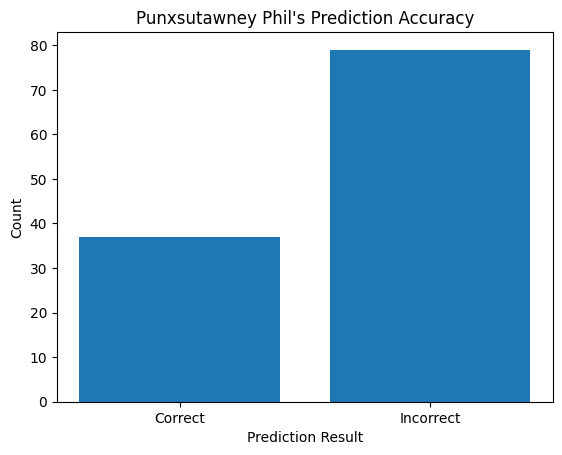

In [ ]:
#bar graph
correct = (df['Phil_Prediction'] == df['Actual Outcome']).sum()
incorrect = len(df) - correct
categories = ['Correct', 'Incorrect']
counts = [correct, incorrect]

plt.bar(categories, counts)
plt.xlabel('Prediction Result')
plt.ylabel('Count')
plt.title("Punxsutawney Phil's Prediction Accuracy")
plt.show()